In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import dump, load

from xai_aux import CFCalculations

In [2]:
def get_distance(A,B, continuous_columns, categorical_columns, l_norm=2):
    
    combined = np.vstack((A, B))
    
    stds = np.std(combined[:, categorical_columns], axis=0)
    epsilon = 1e-8
    adjusted_stds = np.where(stds == 0, epsilon, stds) 

    weights_categorical = 1.48 / adjusted_stds
    mads = np.median(np.abs(combined[:, continuous_columns] - 
                            np.median(combined[:, continuous_columns], axis=0)), axis=0)
    adjusted_mads = np.where(mads == 0, epsilon, mads) 
    weights_continuous = 1 / adjusted_mads

    # Combine weights
    weights = np.zeros(combined.shape[1])
    weights[categorical_columns] = weights_categorical
    weights[continuous_columns] = weights_continuous

    # Compute weighted L2 distances for same-index pairs
    differences = A - B  # Element-wise differences
    weighted_differences = differences * weights  # Apply weights element-wise
    l_distances = np.linalg.norm(weighted_differences, axis=1, ord=l_norm)
    return l_distances

In [3]:
colours = {('lr', 'skl'): 'deepskyblue', 
           ('lr', 'blr_marg'): 'blue', 
           ('lr', 'blr_mean'): 'lightblue',
           ('lr', 'nice'): 'magenta',
           ('lr', 'dice'): 'hotpink', 
           ('lr', 'RL'): 'lavender',
           ('rf', 'nice'): 'darkorange',
           ('rf', 'dice'): 'orange',
           ('rf', 'RL'): 'palegoldenrod',
           ('tf', 'nice'): 'darkgreen', 
           ('tf', 'dice'): 'lightgreen'
           }

In [4]:
mock_data = 4
mock_data_flag = True
german_credit_flag = True
adult_income_flag = True
gsc_flag = True
l_order = 2
cm = ['TP','FP','FN','TN']

In [5]:
if mock_data_flag:
    mock_data_ext = str(mock_data)#+"_noniid_test" #"_ommited_var_test"
    cf_results_dict = load("data/cf_results_dict_mock_data"+mock_data_ext+".pkl")
    cf_calc = load("data/cf_calc_mock_data"+mock_data_ext+".pkl")
    model_results_dict = load("data/model_results_dict"+mock_data_ext+".pkl")
    cfs_good_indices = load("data/cfs_good_indices"+mock_data_ext+".pkl")

if german_credit_flag:
    cf_results_dict = load("data/cf_results_dict_german_credit.pkl")
    cf_calc = load("data/cf_calc_mock_data_german_credit.pkl")
    model_results_dict = load("data/model_results_german_credit.pkl")
    cfs_good_indices = load("data/cfs_good_indices_german_credit.pkl")

if adult_income_flag:
    cf_results_dict = load("data/cf_results_dict_adult_income.pkl")
    cf_calc = load("data/cf_calc_adult_income.pkl")
    model_results_dict = load("data/model_results_adult_income.pkl")
    cfs_good_indices = load("data/cfs_good_indices_adult_income.pkl")

if adult_income_flag:
    cf_results_dict = load("data/cf_results_dict_gsc.pkl")
    cf_calc = load("data/cf_calc_gsc.pkl")
    model_results_dict = load("data/model_results_gsc.pkl")
    cfs_good_indices = load("data/cfs_good_indices_gsc.pkl")

In [6]:
noises_list = list(cf_results_dict.keys())[1:]
cf_methods = list(cf_results_dict[noises_list[0]].keys())
n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
numerical_columns = [int(i) for i in cf_calc.num_cols_tf]
categorical_columns = [int(i) for i in cf_calc.cat_cols_tf]

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/co

IndexError: list index out of range

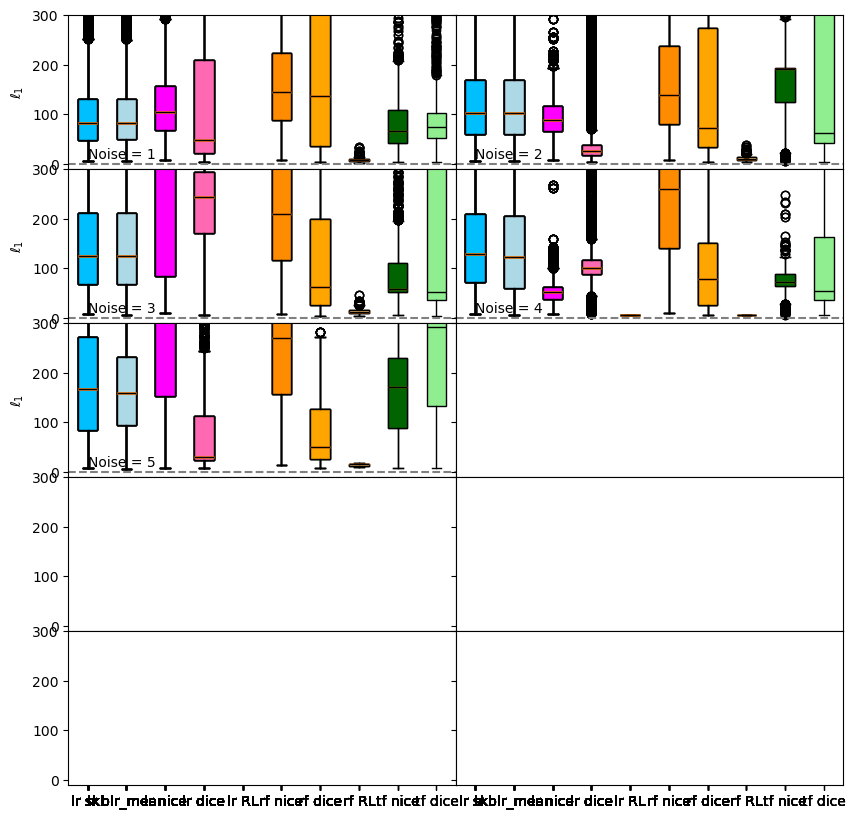

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()
for i, ax in enumerate(axes):
    d2 = []
    labels = []
    colour_list = []
    for k in cf_methods:
        colour_list.append(colours[k]) #create correct colour list
        A = cf_results_dict[noises_list[i]][k]
        B = cf_results_dict['noise_0'][k]

        if k[1]=='nice' or k[1]=='dice' or k[1]=='RL':
            if k[0]!='tf':
                A = cf_calc.models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                B = cf_calc.models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[noises_list[i]][k]
        d2.append(get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order))
        #d2.append(get_distance(A, B, numerical_columns, categorical_columns, l_norm=l_order))
        labels.append(k[0]+' ' + k[1])
        bplot = ax.boxplot(d2, tick_labels=labels, widths=0.5, patch_artist=True)
    for patch, color in zip(bplot['boxes'], colour_list):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')

    #ax.set_ylim(y_lim)
    fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
    ax.tick_params(axis='x', labelrotation=45)
    ax.text(1,12,'Noise = ' + noises_list[i][6:9])
    # if i==0:
    #     ax.text(1,45,cm_in)
    ax.axhline(y=0,linestyle='--',color='grey')
    if np.mod(i,2)==0:
        ax.set_ylabel(r'$\ell_1$')
    plt.ylim([-10, 300])

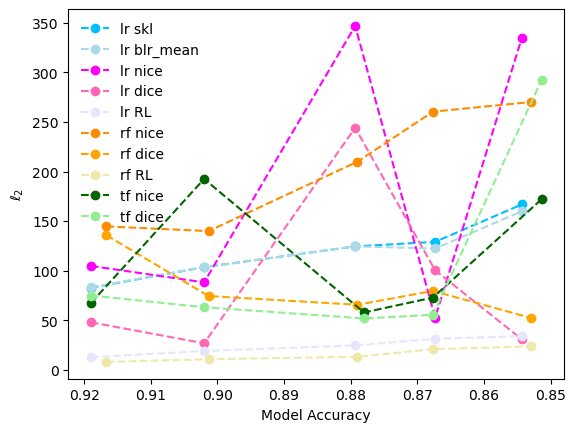

In [9]:
for i, kk in enumerate(cf_methods):
    x_acc = []
    d2 = []
    for k in cf_results_dict:
        if k=='noise_0': continue
        x_acc.append(model_results_dict[k][(kk[0],'accuracy')])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]
        if kk[1]=='nice' or kk[1]=='dice' or kk[1]=='RL':
            if kk[0]!='tf':
                A = cf_calc.models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                B = cf_calc.models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        #good_indices = cfs_good_indices[k][kk] # we ignore that because it won't work for plotting. This is a >5% level effect.
        d2.append(get_distance(A, B, numerical_columns, categorical_columns, l_norm=l_order))
        
    d2 = np.array(d2)
    plt.plot(x_acc, np.median(d2, axis=1), color=colours[kk],label=kk[0]+' '+kk[1],alpha=1, linestyle='--', marker='o')
    #plt.fill_between(x_acc, np.percentile(d2,40,axis=1), np.percentile(d2,60,axis=1), color=colours[kk],alpha=0.2)
plt.legend(frameon=False)
plt.ylabel(r'$\ell_2$')
plt.xlabel('Model Accuracy')
plt.gca().invert_xaxis()
# if mock_data=="1":
#plt.ylim([8, 30])